Balanced accuracy was not great (.8) on the #2 draft. This is a new attempt.

0) Setup: imports, reproducibility, GPU check

In [1]:
import os, random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision policy:", mixed_precision.global_policy())

AUTOTUNE = tf.data.AUTOTUNE





TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


In [2]:
!nvidia-smi


Tue Feb 17 17:53:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   64C    P8             17W /   72W |       3MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

1) Load EuroSAT from Hugging Face and build tensors

In [3]:
!pip -q install datasets
from datasets import load_dataset

ds_hf = load_dataset("blanchon/EuroSAT_RGB")

NUM_CLASSES = ds_hf["train"].features["label"].num_classes
label_names = ds_hf["train"].features["label"].names
print("NUM_CLASSES:", NUM_CLASSES)
print("Classes:", label_names)

IMG_H, IMG_W = 64, 64
BATCH_SIZE = 256




/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


NUM_CLASSES: 10
Classes: ['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial Buildings', 'Pasture', 'Permanent Crop', 'Residential Buildings', 'River', 'SeaLake']


In [4]:
def hf_to_tfds(hf_split, training: bool):
    def gen():
        for ex in hf_split:
            img = np.array(ex["image"], dtype=np.uint8)  # (64,64,3)
            y = int(ex["label"])
            yield img, y

    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(IMG_H, IMG_W, 3), dtype=tf.uint8),
            tf.TensorSpec(shape=(), dtype=tf.int32),
        ),
    )

    def preprocess(x, y):
        x = tf.cast(x, tf.float32) / 255.0            # normalize to [0,1]
        y = tf.one_hot(y, NUM_CLASSES)                # one-hot encoding
        return x, y

    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.shuffle(20_000, seed=SEED, reshuffle_each_iteration=True)


    ds = ds.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)
    return ds

train_ds = hf_to_tfds(ds_hf["train"], training=True)
val_ds   = hf_to_tfds(ds_hf["validation"], training=False)
test_ds  = hf_to_tfds(ds_hf["test"], training=False)

for xb, yb in train_ds.take(1):
    print("X:", xb.shape, xb.dtype, "| y:", yb.shape, yb.dtype)


X: (256, 64, 64, 3) <dtype: 'float32'> | y: (256, 10) <dtype: 'float32'>


2) Functional CNN

In [5]:
data_augment = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.12),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ],
    name="augmentation",
)



In [6]:
def build_functional_cnn_noaug(input_shape=(64, 64, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape, name="input")
    x = inputs

    # Block 1
    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(128, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)
    return keras.Model(inputs, outputs, name="EuroSAT_CNN_noaug")


3) Build model

In [7]:
model = build_functional_cnn_noaug((IMG_H, IMG_W, 3), NUM_CLASSES)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy", keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc")],
)

callbacks = [
    keras.callbacks.ModelCheckpoint("best_cnn.keras", monitor="val_accuracy", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True),
]

history = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks, verbose=1)
model.evaluate(test_ds, verbose=1)




Epoch 1/20
     64/Unknown 96s 547ms/step - accuracy: 0.5912 - loss: 1.2346 - top3_acc: 0.8068

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


64/64 ━━━━━━━━━━━━━━━━━━━━ 106s 700ms/step - accuracy: 0.5928 - loss: 1.2294 - top3_acc: 0.8083 - val_accuracy: 0.1044 - val_loss: 2.4609 - val_top3_acc: 0.3300
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8115 - loss: 0.5574 - top3_acc: 0.9701 - val_accuracy: 0.1044 - val_loss: 3.5724 - val_top3_acc: 0.4246
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8486 - loss: 0.4455 - top3_acc: 0.9799 - val_accuracy: 0.1044 - val_loss: 5.0268 - val_top3_acc: 0.3343
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8721 - loss: 0.3804 - top3_acc: 0.9869 - val_accuracy: 0.1083 - val_loss: 5.3216 - val_top3_acc: 0.3343
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8902 - loss: 0.3255 - top3_acc: 0.9896 - val_accuracy: 0.1400 - val_loss: 5.0427 - val_top3_acc: 0.3465
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9059 - loss: 0.2810 - top3_acc: 0.9920 - val_accuracy: 0.1885 - val_loss: 4.8344 - val_top3_acc: 0

[0.270201176404953, 0.9072222113609314, 0.9912962913513184]

4) Evaluate

In [8]:
best = keras.models.load_model("best_cnn.keras")
best.evaluate(test_ds, verbose=1)


22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.9222 - loss: 0.2285 - top3_acc: 0.9936


[0.270201176404953, 0.9072222113609314, 0.9912962913513184]

In [9]:
!pip -q install scikit-learn
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

def preds_and_true(model, ds):
    y_true, y_pred = [], []
    for xb, yb in ds:
        probs = model.predict(xb, verbose=0)
        y_true.append(np.argmax(yb.numpy(), axis=1))
        y_pred.append(np.argmax(probs, axis=1))
    return np.concatenate(y_true), np.concatenate(y_pred)

y_true, y_pred = preds_and_true(model, test_ds)

bal_acc = balanced_accuracy_score(y_true, y_pred)
print("Balanced accuracy:", bal_acc)

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=label_names))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion matrix shape:", cm.shape)


Balanced accuracy: 0.9032306428281347

Classification report:
                       precision    recall  f1-score   support

          Annual Crop       0.86      0.97      0.91       596
               Forest       0.99      0.95      0.97       608
Herbaceous Vegetation       0.81      0.91      0.86       573
              Highway       0.91      0.76      0.83       496
 Industrial Buildings       0.98      0.89      0.93       501
              Pasture       0.92      0.89      0.90       396
       Permanent Crop       0.79      0.91      0.84       538
Residential Buildings       0.97      0.95      0.96       554
                River       0.90      0.85      0.88       529
              SeaLake       0.99      0.96      0.97       609

             accuracy                           0.91      5400
            macro avg       0.91      0.90      0.91      5400
         weighted avg       0.91      0.91      0.91      5400


Confusion matrix shape: (10, 10)


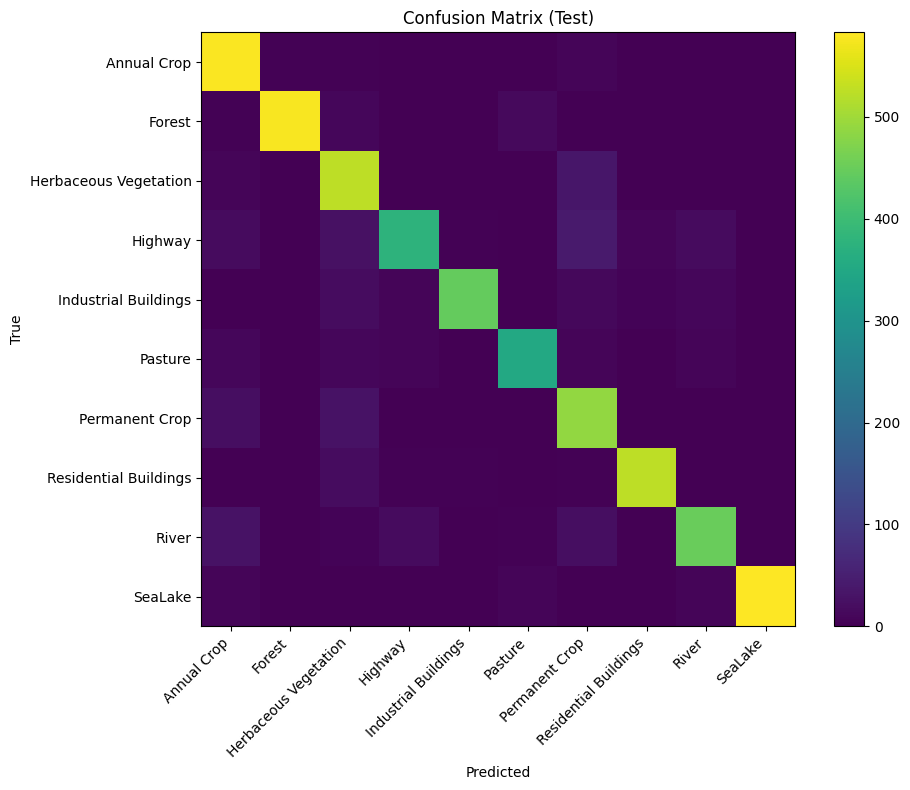

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (Test)")
plt.colorbar()
ticks = np.arange(NUM_CLASSES)
plt.xticks(ticks, label_names, rotation=45, ha="right")
plt.yticks(ticks, label_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()
